# 06 — Interpretaciones alternativas del criterio de éxito

El enunciado pide «tasa de captura > 90 % en menos de 40 pasos por episodio», con $d_b \in [5, 40]$ m, pero
**no define** cuánto dura un «paso» (habla de «macro-acciones») ni la **forma** de la distribución de $d_b$.
La implementación principal (notebooks 01–03) supone **1 paso = 1 ciclo del servidor** (100 ms) y **$d_b$ uniforme**.

Este notebook mide, en el simulador y en el servidor real, dos lecturas alternativas:

1. **$d_b$ concentrado en distancias cortas** dentro del mismo rango [5, 40] m: densidad triangular
   ∝ (40 − d). Se evalúa la **misma política** del informe, sin reentrenar.
2. **Un paso = k ciclos** (macro-acción, k = 2 y 3): cada decisión repite su comando durante k ciclos. Requiere
   **reentrenar**, porque cambia la dinámica que ve el agente.

**Alcance:** estos resultados muestran qué pasaría **si** el docente confirma una de estas lecturas. No
reemplazan los resultados principales ni demuestran cumplimiento bajo la lectura implementada. La densidad
triangular y los valores de k son elecciones nuestras para cuantificar el efecto; el enunciado no los fija.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots

ART = "notebooks/artifacts"
def rate(eps, budget=39):
    ok = [e for e in eps if "error" not in e]
    p = np.mean([(e["capture_step"] or 10**6) <= budget for e in ok])
    return p, np.sqrt(p * (1 - p) / len(ok)), len(ok)
def row(label, res):
    out = []
    for env in ("sim", "live"):
        eps = [e for e in res[env] if "error" not in e]
        p, se, n = rate(eps); q, _, _ = rate(eps, 40)
        out.append(f"| {label} | {'simulador' if env == 'sim' else 'servidor'} | {n} | {p:.1%} (± {se:.1%}) | {q:.1%} | "
                   f"{np.mean([e['steps'] for e in eps]):.1f} | {np.mean([e.get('cycles') or e['steps'] for e in eps]):.1f} |")  # k = 1: cycles = steps
    return out
HEAD = ["| lectura | entorno | n | captura < 40 pasos | ≤ 40 pasos | pasos medios | ciclos medios |",
        "|---|---|---|---|---|---|---|"]

## 1. Distribución de $d_b$ concentrada en distancias cortas

Misma política del informe (Q-Learning, ε decreciente, semilla 4, k = 1), mismos 200 inicios por posición y
rumbo, con $d_b$ triangular sobre [5, 40] m en lugar de uniforme. La evaluación uniforme del notebook 03 se
muestra como referencia.

In [2]:
base = json.load(open(f"{ART}/live_eval_seed_4_200.json"))
near = json.load(open(f"{ART}/live_eval_seed_4_near_200.json"))
lines = HEAD + row("d_b uniforme (implementada)", base) + row("d_b triangular (cercanos)", near)
display(Markdown("\n".join(lines)))
share = np.mean([e["start"]["distance"] >= 30 for e in near["live"] if "error" not in e])
print(f"inicios con d_b >= 30 m en la muestra triangular: {share:.1%} (uniforme: 28.6 % esperado)")
print("estadísticas en vivo:", near["summary"]["stats"])

| lectura | entorno | n | captura < 40 pasos | ≤ 40 pasos | pasos medios | ciclos medios |
|---|---|---|---|---|---|---|
| d_b uniforme (implementada) | simulador | 200 | 71.5% (± 3.2%) | 74.5% | 30.2 | 30.2 |
| d_b uniforme (implementada) | servidor | 200 | 73.5% (± 3.1%) | 76.5% | 30.1 | 30.1 |
| d_b triangular (cercanos) | simulador | 200 | 92.5% (± 1.9%) | 93.0% | 24.8 | 24.8 |
| d_b triangular (cercanos) | servidor | 200 | 92.5% (± 1.9%) | 93.5% | 24.6 | 24.6 |

inicios con d_b >= 30 m en la muestra triangular: 7.5% (uniforme: 28.6 % esperado)
estadísticas en vivo: {'missed_commands': 0, 'late_see': 1636, 'stale_see': 0, 'cycles': 5121, 'resets': 200}


## 2. Un paso = k ciclos (macro-acciones)

**Definición implementada** (`src/env_base.py`):
- una decisión repite su comando durante k ciclos consecutivos. El servidor ejecuta un comando de cuerpo por
  ciclo, así que un `TURN +35` mantenido sigue girando;
- el estimador se actualiza y la captura se verifica **en cada ciclo**: el episodio termina en el ciclo exacto de
  la captura, aunque sea a mitad de la macro-acción;
- la recompensa sigue el enunciado **por paso de decisión**: distancia ganada en la macro-acción − 0.2 + 100 si
  hay captura;
- el presupuesto es de 40 pasos de decisión (= 40·k ciclos).

Todo lo demás es idéntico al baseline: representación C, α = 0.03, γ = 0.99, ε 1.0 → 0.1, 20 000 episodios,
5 semillas y los mismos 500 inicios de evaluación. k = 1 reproduce exactamente las corridas del informe.
Regenerar: `python -m src.train --preset macro --out notebooks/artifacts/runs_macro`.

| k | tiempo físico máx. | final < 40 pasos | últimas 5 < 40 | peor de últimas 5 | ciclos medios hasta captura |
|---|---|---|---|---|---|
| 1 | 3.9 s | 0.738 ± 0.006 | 0.739 ± 0.007 | 0.708 | 26.2 |
| 2 | 7.8 s | 0.981 ± 0.024 | 0.982 ± 0.004 | 0.934 | 34.6 |
| 3 | 11.7 s | 0.958 ± 0.012 | 0.944 ± 0.034 | 0.638 | 50.9 |

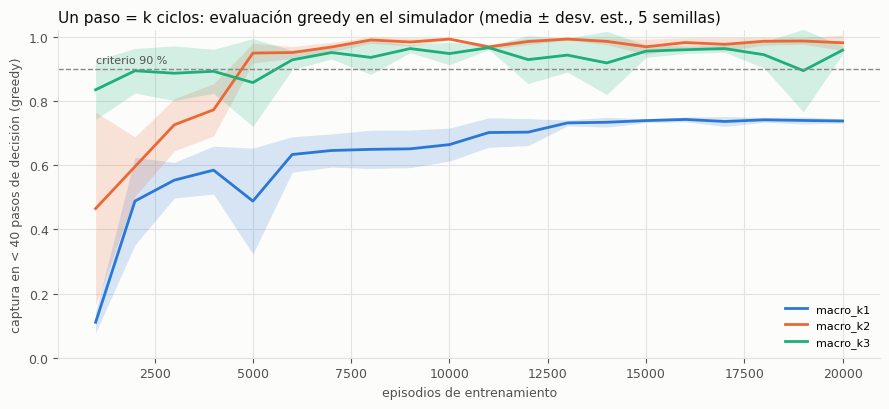

In [3]:
runs = plots.load_runs(f"{ART}/runs_macro")
lines = ["| k | tiempo físico máx. | final < 40 pasos | últimas 5 < 40 | peor de últimas 5 | ciclos medios hasta captura |", "|---|---|---|---|---|---|"]
for name, rs in runs.items():
    k = rs[0]["config"]["cycles_per_step"]
    final = [r["final_eval"]["capture_rate_lt40"] for r in rs]
    last5 = [np.mean([e["capture_rate_lt40"] for e in r["evals"][-5:]]) for r in rs]
    worst = min(min(e["capture_rate_lt40"] for e in r["evals"][-5:]) for r in rs)
    cyc = [r["final_eval"]["mean_capture_cycles"] for r in rs if r["final_eval"]["mean_capture_cycles"] is not None]
    lines.append(f"| {k} | {3.9 * k:.1f} s | {np.mean(final):.3f} ± {np.std(final):.3f} | {np.mean(last5):.3f} ± {np.std(last5):.3f} | "
                 f"{worst:.3f} | {np.mean(cyc):.1f} |")
display(Markdown("\n".join(lines)))
fig, ax = plt.subplots(figsize=(9, 4.2))
plots.plot_eval_curves(runs, "capture_rate_lt40", refs={"criterio 90 %": 0.9}, ax=ax, direct_labels=False,
                       ylabel="captura en < 40 pasos de decisión (greedy)",
                       title="Un paso = k ciclos: evaluación greedy en el simulador (media ± desv. est., 5 semillas)")
ax.set_ylim(0, 1.02)
fig.tight_layout(); fig.savefig(f"{ART}/fig_macro_eval.png", dpi=200)

### Evaluación en el servidor

Para cada k se evalúa en vivo la semilla con mejor evaluación final (`live_policy_macro_k*.txt`), sobre 200 inicios
distintos de los de entrenamiento y evaluación (semilla 2026), así que las cifras en vivo no arrastran el sesgo de
esa selección.

In [4]:
lines = list(HEAD) + row("k = 1 (implementada)", base)
for k in (2, 3):
    res = json.load(open(f"{ART}/live_eval_macro_k{k}_200.json"))
    lines += row(f"k = {k}", res)
    st = res["summary"]["stats"]
    print(f"k = {k}: episodios {res['summary']['live']['n']}, comandos no ejecutados {st['missed_commands']}, "
          f"errores {sum('error' in e for e in res['live'])}, cambios de modo {len(res['mode_changes'])}")
display(Markdown("\n".join(lines)))

k = 2: episodios 200, comandos no ejecutados 0, errores 0, cambios de modo 0
k = 3: episodios 200, comandos no ejecutados 0, errores 0, cambios de modo 0


| lectura | entorno | n | captura < 40 pasos | ≤ 40 pasos | pasos medios | ciclos medios |
|---|---|---|---|---|---|---|
| k = 1 (implementada) | simulador | 200 | 71.5% (± 3.2%) | 74.5% | 30.2 | 30.2 |
| k = 1 (implementada) | servidor | 200 | 73.5% (± 3.1%) | 76.5% | 30.1 | 30.1 |
| k = 2 | simulador | 200 | 100.0% (± 0.0%) | 100.0% | 17.8 | 35.0 |
| k = 2 | servidor | 200 | 99.5% (± 0.5%) | 99.5% | 18.1 | 35.7 |
| k = 3 | simulador | 200 | 98.0% (± 1.0%) | 98.0% | 17.7 | 52.0 |
| k = 3 | servidor | 200 | 96.0% (± 1.4%) | 96.5% | 18.2 | 53.5 |

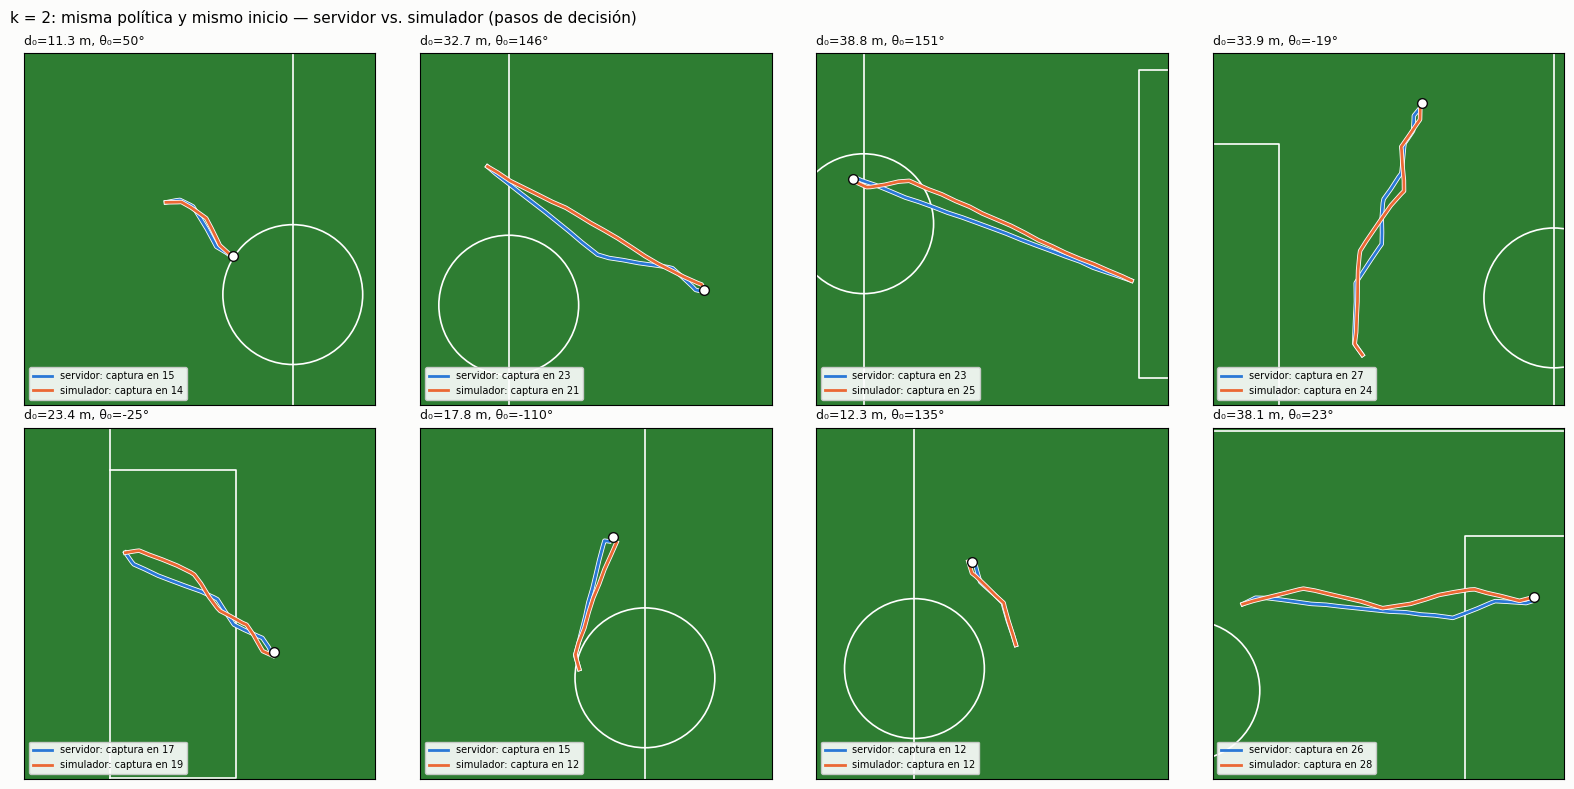

In [5]:
res2 = json.load(open(f"{ART}/live_eval_macro_k2_200.json"))
pairs = [(l, s) for l, s in zip(res2["live"], res2["sim"]) if "trajectory" in l and "trajectory" in s][:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for (l, s), ax in zip(pairs, axes.ravel()):
    plots.plot_trajectory_pair(l, s, ax=ax)
fig.suptitle("k = 2: misma política y mismo inicio — servidor vs. simulador (pasos de decisión)", x=0.01, ha="left", fontsize=11)
fig.tight_layout(); fig.savefig(f"{ART}/fig_macro_k2_trajectories.png", dpi=200)

## 3. Resumen

La tabla reúne, para cada lectura, la tasa de captura **en el servidor** con < 40 pasos. Las cifras del
simulador están en las secciones anteriores.

In [6]:
rows = ["| lectura del enunciado | qué cambia | reentrena | servidor: captura < 40 pasos |", "|---|---|---|---|"]
def live_rate(path):
    p, se, n = rate(json.load(open(path))["live"]); return f"{p:.1%} (± {se:.1%}, n = {n})"
rows.append(f"| **implementada:** 1 paso = 1 ciclo, d_b uniforme | — | — | {live_rate(f'{ART}/live_eval_seed_4_200.json')} |")
rows.append(f"| d_b concentrado en distancias cortas (triangular) | evaluación | no | {live_rate(f'{ART}/live_eval_seed_4_near_200.json')} |")
for k in (2, 3):
    rows.append(f"| 1 paso = {k} ciclos | dinámica por decisión | sí | {live_rate(f'{ART}/live_eval_macro_k{k}_200.json')} |")
display(Markdown("\n".join(rows)))

| lectura del enunciado | qué cambia | reentrena | servidor: captura < 40 pasos |
|---|---|---|---|
| **implementada:** 1 paso = 1 ciclo, d_b uniforme | — | — | 73.5% (± 3.1%, n = 200) |
| d_b concentrado en distancias cortas (triangular) | evaluación | no | 92.5% (± 1.9%, n = 200) |
| 1 paso = 2 ciclos | dinámica por decisión | sí | 99.5% (± 0.5%, n = 200) |
| 1 paso = 3 ciclos | dinámica por decisión | sí | 96.0% (± 1.4%, n = 200) |

**Lectura** (servidor, 200 episodios por fila):
- **Lectura implementada** (1 paso = 1 ciclo, $d_b$ uniforme): 73.5 % ± 3.1.
- **$d_b$ concentrado en distancias cortas:** la **misma política**, sin cambios, captura el 92.5 % ± 1.9.
- **1 paso = 2 ciclos** (40 pasos = 8 s de tiempo físico): una política reentrenada con la misma
  representación e hiperparámetros captura el 99.5 % ± 0.5, incluidos los inicios a más de 35 m.
- **1 paso = 3 ciclos:** 96.0 % ± 1.4.
- El simulador coincide con el servidor en todas las filas, dentro del error muestral.

Esto **respalda** que el déficit frente al criterio depende fuertemente de dos supuestos que el enunciado no
fija: la duración del paso y la forma de la distribución de $d_b$. **No demuestra** que el docente haya querido
decir eso: la densidad triangular y los valores de k son elecciones nuestras. Además, la política del informe es
la de la lectura implementada. Qué resultado reportar como principal depende de la aclaración del docente.